# This notebook regroups the code around the Heatmap of AMI (generation with MF and estimation with NRS)

## Packages and Import

In [ ]:
#!pip install seaborn
#!pip install pandas
#!pip install matplotlib
#!pip install scikit-learn

In [1]:
# bibliothéques fondamentales
import matplotlib.pyplot as plt
import pandas as pd
#import bipartitepandas as bpd
import numpy as np
import time
import random
pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning

# Pour faire du ML/DL
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import LabelEncoder
simplefilter("ignore", category=ConvergenceWarning) # Useful for logistic regression

from tensorflow.keras.layers import Input, Dot, Embedding, Add, Flatten, Activation, Layer # Optimisation via tensorflow.keras
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback

pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning
import tensorflow as tf
from keras import regularizers
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Confusion Matrix

# Pour visualisation/ réduction de dimension
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
import pacmap
import seaborn as sns
# Clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn import metrics

# Pour stocker un tuple
import pickle

# Pour calcul de similarité entre les matrices
from numpy.linalg import norm
from sklearn.metrics.pairwise import cosine_similarity

# Afficher un cercle autour d'un point
import matplotlib.patches as patches

# Pour rafraichir les scripts des modules sans redémarrer le kernel
import importlib

# Pour compter le temps d'exécution d'une fonction
import time

2024-08-29 09:31:09.240428: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-29 09:31:09.242670: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-08-29 09:31:09.281164: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-08-29 09:31:09.293925: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-29 09:31:09.315321: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

In [62]:
# module maison
import script.decorateur as decorateur
import script.graph_formation as graph_formation
import script.MF_NRS as MF_NRS
import script.simulation as simulation
import script.metrique as metrique
import script.animation as animation
import script.plot_functions as plot_functions

# importe la classe directement
GraphFormation = graph_formation.GraphFormation
get_estimations = MF_NRS.get_estimations


# Recharge les modules (A executer en cas de modification des scripts, cela permet d'éviter de restart le kernel)
importlib.reload(decorateur)
importlib.reload(graph_formation)
importlib.reload(MF_NRS)
importlib.reload(simulation)
importlib.reload(metrique)
importlib.reload(animation)
importlib.reload(plot_functions)

<module 'script.plot_functions' from '/home/onyxia/work/G4H_AKM_RS_NRS/script/plot_functions.py'>

## Formation de la matrice HeatMap 

### NRS

In [ ]:
matrix = simulation.make_matrix_heatmap(dim_gen_array = np.array([1,2,3,4,5]), dim_estim_array = np.array([1, 2, 3, 4, 5, 8, 10]), nb_epochs_max = 100, name_file = "matrix_heatmap_NRS_seed12")

graph formation: done
first estimation: done
second estimation: done
(1000, 1)
(50, 1)
clustering: done
first estimation: done
second estimation: done
(1000, 2)
(50, 2)
clustering: done
first estimation: done
second estimation: done
(1000, 3)
(50, 3)
clustering: done
first estimation: done
second estimation: done
(1000, 4)
(50, 4)
clustering: done


In [ ]:
matrix = simulation.make_matrix_heatmap(dim_gen_array = np.array([1,2,3,4,5]), dim_estim_array = np.array([1, 2, 3, 4, 5, 8, 10]), nb_epochs_max = 100, seed = 13, name_file = "matrix_heatmap_NRS_seed13")

In [ ]:
matrix = simulation.make_matrix_heatmap(dim_gen_array = np.array([1,2,3,4,5]), dim_estim_array = np.array([1, 2, 3, 4, 5, 8, 10]), nb_epochs_max = 100, seed = 14, name_file = "matrix_heatmap_NRS_seed14")

graph formation: done
first estimation: done
second estimation: done
(1000, 1)
(50, 1)
clustering: done
first estimation: done
second estimation: done
(1000, 2)
(50, 2)
clustering: done
first estimation: done
second estimation: done
(1000, 3)
(50, 3)
clustering: done
first estimation: done
second estimation: done
(1000, 4)
(50, 4)
clustering: done
first estimation: done
second estimation: done
(1000, 5)
(50, 5)
clustering: done
first estimation: done
second estimation: done
(1000, 8)
(50, 8)
clustering: done
first estimation: done
second estimation: done
(1000, 10)
(50, 10)
clustering: done
graph formation: done
first estimation: done
second estimation: done
(1000, 1)
(50, 1)
clustering: done
first estimation: done
second estimation: done
(1000, 2)
(50, 2)
clustering: done
first estimation: done
second estimation: done
(1000, 3)
(50, 3)
clustering: done
first estimation: done
second estimation: done
(1000, 4)
(50, 4)
clustering: done
first estimation: done
second estimation: done
(1000

### MF

In [ ]:
simulation.make_matrix_heatmap(dim_gen_array = np.array([1,2,3,4,5]), dim_estim_array = np.array([1, 2, 3, 4, 5, 8, 10]), algorithm = "MF", nb_epochs_max = 120, name_file = "matrix_heatmap_MF_seed12")

## Visualisation de la Heatmap

### Seed 12

In [63]:
with open('Simulations/matrix_heatmap_NRS_seed12.npy', 'rb') as f:
    matrix_heatmap_NRS = np.load(f)

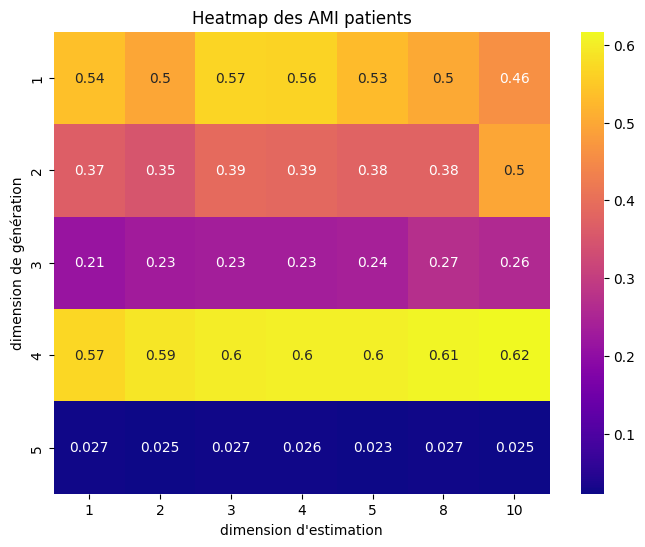

In [68]:
plot_functions.plot_heatmap(matrix_heatmap_NRS, who="patient", title = "Heatmap des AMI patients")

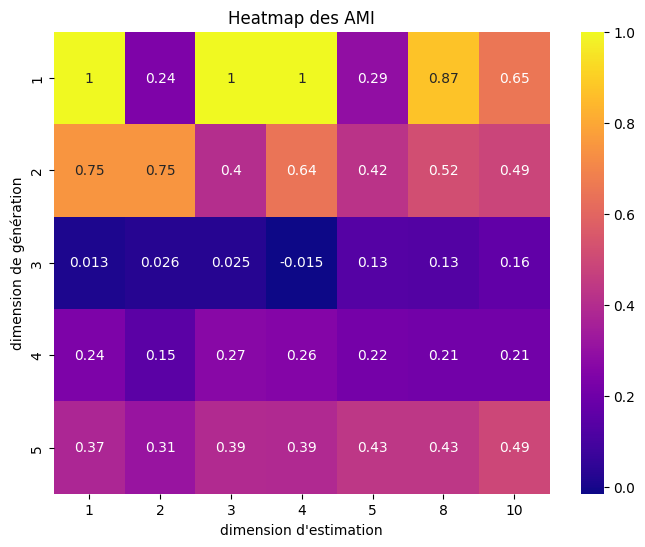

In [65]:
plot_functions.plot_heatmap(matrix_heatmap_NRS, who="doctor", title = "Heatmap des AMI docteurs")

### Seed 13

In [91]:
with open('Simulations/matrix_heatmap_NRS_seed13.npy', 'rb') as f:
    matrix_heatmap_NRS = np.load(f)

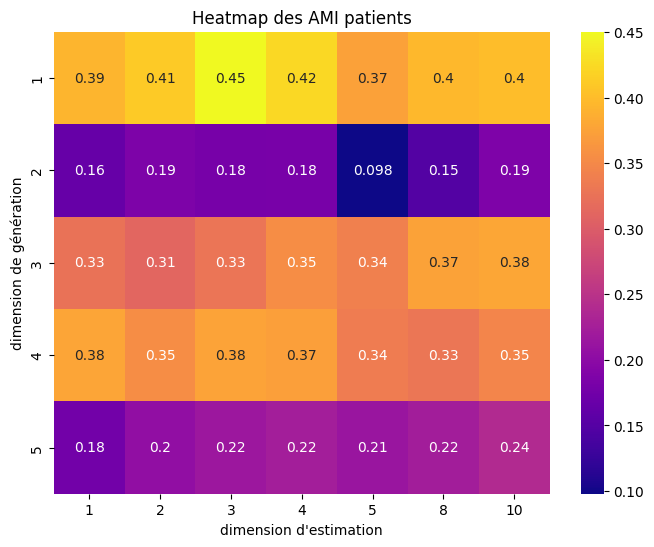

In [92]:
plot_functions.plot_heatmap(matrix_heatmap_NRS, who="patient", title = "Heatmap des AMI patients")

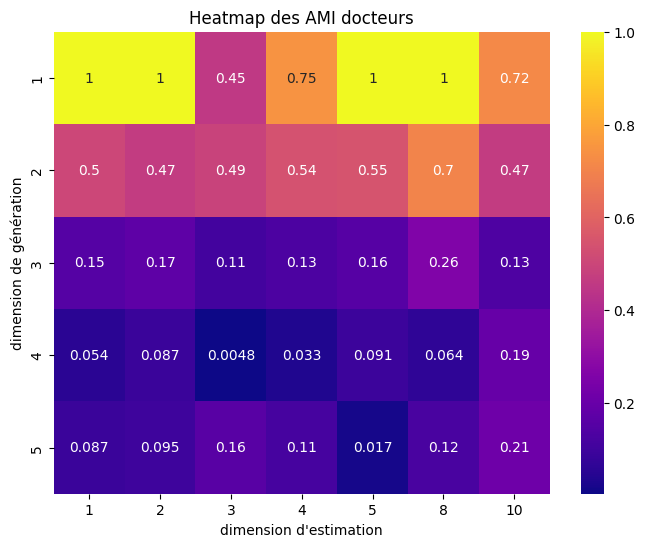

In [93]:
plot_functions.plot_heatmap(matrix_heatmap_NRS, who="doctor", title = "Heatmap des AMI docteurs")

### Seed 14

In [97]:
with open('Simulations/matrix_heatmap_NRS_seed14.npy', 'rb') as f:
    matrix_heatmap_NRS = np.load(f)

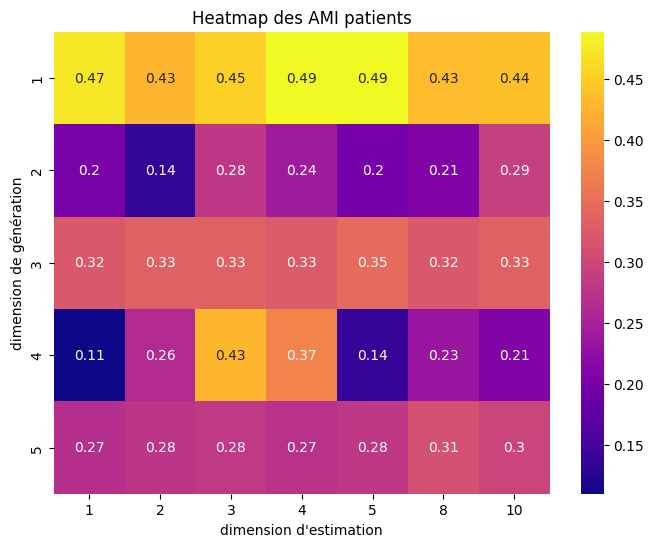

In [98]:
plot_functions.plot_heatmap(matrix_heatmap_NRS, who="patient", title = "Heatmap des AMI patients")

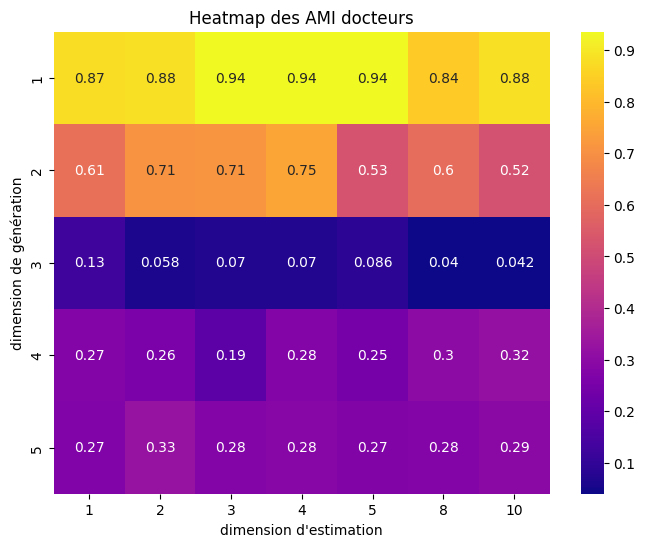

In [99]:
plot_functions.plot_heatmap(matrix_heatmap_NRS, who="doctor", title = "Heatmap des AMI docteurs")

### Seed 12 (MF)

In [101]:
with open('Simulations/matrix_heatmap_MF_seed12.npy', 'rb') as f:
    matrix_heatmap_NRS = np.load(f)

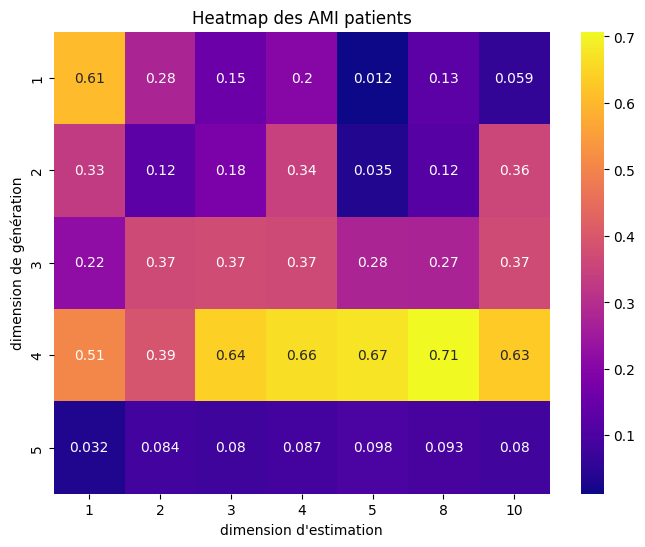

In [102]:
plot_functions.plot_heatmap(matrix_heatmap_NRS, who="patient", title = "Heatmap des AMI patients")

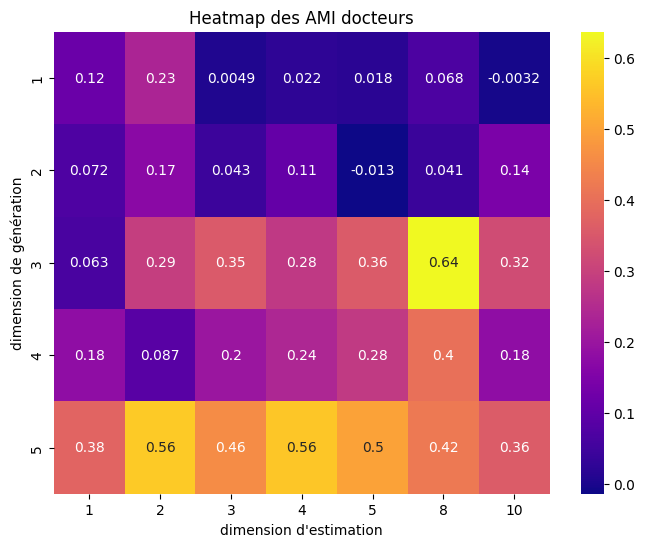

In [103]:
plot_functions.plot_heatmap(matrix_heatmap_NRS, who="doctor", title = "Heatmap des AMI docteurs")